In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

In [2]:
e=np.array(0.001)

In [3]:
max=[]
dim=[]
J=[]
for n in range(2,21):
    dim.append(n)
    N=str(n)
    A=np.random.rand(n)
    A=np.outer(A,A)
    d=[]
    M=[]
    for m in range(1,n**2):
        M.append(m)
        om=[]
        om.append(np.random.randint(0,n,size=2))
        while (len(om)!=m):
            a=[]
            l=np.random.randint(0,n,2)
            for j in range(len(om)):
                if(l!=om[j]).any():
                    a.append(True)
                elif(l==om[j]).all():
                    a.append(False)
            a=np.array(a)
            if a.all():
                om.append(l)
        om=np.array(om)

        X = cp.Variable((n,n))

        obj = cp.norm(X,"nuc")

        constraints = []
        for i in range(m):
            constraints += [X[om[i,0],om[i,1]] == A[om[i,0],om[i,1]]]

        p = cp.Problem(cp.Minimize(obj),constraints)
        p.solve()
        S=np.array(X.value)
        A=np.array(A)
        d.append(np.linalg.norm(S-A,'nuc'))
    d=d/np.linalg.norm(A,'nuc')
    j=0
    jmax=0
    for i in d:
        j+=1
        if i>e:
            jmax=j+1
    J.append(jmax)
    #plt.plot(M,d,'.')
    #plt.xlabel("Entries known")
    #plt.ylabel("Distance between completed and original matrix")
    #plt.savefig(N)

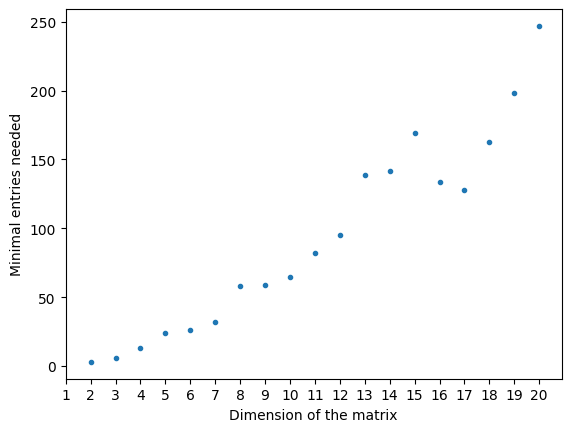

In [4]:
ti=[]
for i in range(1,21):
    ti.append(i)
plt.plot(dim,J,'.')
plt.xlabel("Dimension of the matrix")
plt.ylabel("Minimal entries needed")
plt.xticks(ti)
plt.savefig("Minimal entries needed")